# 08 · Interpretabilidad: ¿en qué se está fijando el modelo?

**Fase CRISP-DM: Interpretación de resultados.**

El notebook 07 dejó a `CatBoost` como campeón (utility 0,3575, AUROC 0,8497). Pero ningún
número dice si el modelo aprendió fisiología real o solo atajos. El notebook 06 encontró que
todo modelo pierde desempeño al cruzar de hospital, y sospechó que los árboles podrían estar
aprendiendo *cómo ese hospital registra sus datos*, no solo al paciente. Este notebook pone
esa sospecha a prueba con evidencia.

### Por qué SHAP y no la importancia nativa del modelo

Los árboles del notebook 06 exponen `feature_importances_`, pero está sesgada hacia variables
con muchos valores distintos — premiaría a los laboratorios continuos sobre las máscaras
binarias sin que eso signifique que aportan más. **SHAP** (SHapley Additive exPlanations)
reparte la predicción de **cada fila** entre sus variables: responde cuánto movió cada
variable el riesgo de *este* paciente en *esta* hora, y en qué dirección.

In [1]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

sys.path.append(str(Path.cwd().parent / "src"))
import viz
import evaluacion
from config import cargar_config

cfg = cargar_config()
matriz = pd.read_parquet(cfg["rutas"]["processed"] / "matriz_features_completa.parquet")
viz.aplicar_estilo()

paquete = joblib.load(cfg["rutas"]["models"] / "modelos_intra_cohorte.joblib")

# El campeón se lee del panel que ordenó el notebook 07, no se vuelve a elegir aquí.
panel = pd.read_csv(cfg["rutas"]["models"] / "resultados_utility_umbral.csv")
NOMBRE_CAMPEON = panel.iloc[0]["modelo"]
UMBRAL = float(panel.iloc[0]["umbral"])

campeon = paquete["modelos"][NOMBRE_CAMPEON]
modelo, cols = campeon["modelo"], campeon["cols"]

test = matriz.loc[paquete["test_idx"]].reset_index(drop=True)
test["score"] = evaluacion.obtener_proba(campeon, test)
test["alarma"] = (test["score"] >= UMBRAL).astype("int8")

print(f"{len(test):,} filas-hora | {test.pid.nunique():,} pacientes | {len(cols)} features")
print(f"modelo campeón (notebook 07, por utility): {NOMBRE_CAMPEON}")
print(f"umbral heredado del notebook 07: {UMBRAL:.4f}")

C:\Users\danie\AppData\Local\hermes\hermes-agent\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


310,997 filas-hora | 8,068 pacientes | 209 features
modelo campeón (notebook 07, por utility): CatBoost
umbral heredado del notebook 07: 0.7838


## 1. Los valores SHAP, sobre una muestra representativa

Calcular SHAP sobre las 310.997 filas del test daría 65 millones de valores sin cambiar
ninguna conclusión — la importancia global converge mucho antes. Tomamos una muestra
**aleatoria** (no equilibrada) de 20.000 filas-hora: queremos la importancia tal como se ve en
la mezcla real de pacientes, no en una cohorte artificialmente balanceada.

In [2]:
muestra = test.sample(n=20_000, random_state=cfg["proyecto"]["semilla"])
X = muestra[cols]

explicador = shap.TreeExplainer(modelo)
shap_exp = explicador(X)

print(f"SHAP calculado sobre {X.shape[0]:,} filas x {X.shape[1]} features "
      f"({muestra.SepsisLabel.sum():,} horas positivas en la muestra)")


SHAP calculado sobre 20,000 filas x 209 features (332 horas positivas en la muestra)


WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_shap_beeswarm.png')

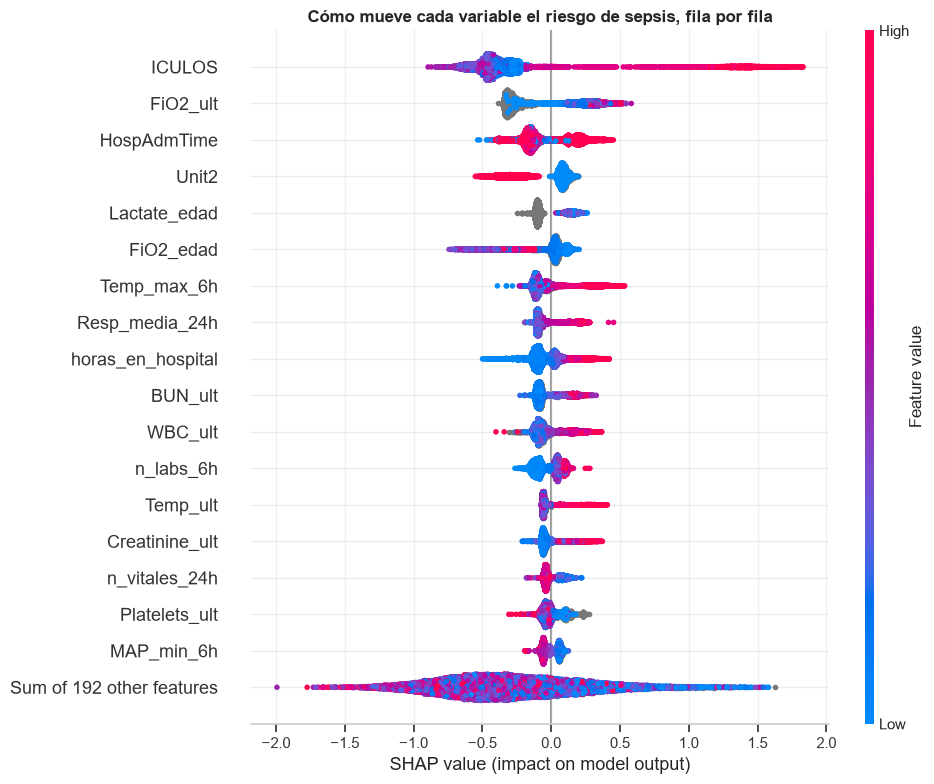

In [3]:
shap.plots.beeswarm(shap_exp, max_display=18, show=False)
fig = plt.gcf()
fig.set_size_inches(10, 8)
plt.title("Cómo mueve cada variable el riesgo de sepsis, fila por fila", fontsize=12, fontweight="bold")
plt.tight_layout();
viz.guardar(fig, "08_shap_beeswarm", cfg)

Cada punto es una fila-hora; su posición horizontal es cuánto empujó esa variable el riesgo de
esa hora, y el color es si el valor era alto (rojo) o bajo (azul).

**Las variables fisiológicas apuntan todas en la dirección clínicamente correcta**: fiebre,
taquipnea, leucocitosis y fallo renal, todas empujan el riesgo hacia arriba. El modelo no está
aprendiendo al revés.

Lo que sí llama la atención es **cuáles ocupan los primeros puestos** — eso es lo que la
siguiente sección mide en vez de dejarlo en una impresión visual.

## 2. ¿Fisiología, o práctica de medición del hospital?

La pregunta que dejó abierta el notebook 06. La matriz mezcla tres tipos de información:

- **Estado fisiológico** — valores, ventanas, basal y scores clínicos. Lo que el cuerpo del
  paciente está haciendo.
- **Práctica de medición** — si se midió, hace cuánto, y la carga de monitoreo. Esto **no**
  describe al paciente: describe qué decidió medir el hospital.
- **Contexto administrativo** — edad, sexo, unidad, horas de estancia.

Si el peso se concentrara en el segundo grupo, el modelo sería en buena parte un detector de
"a este paciente lo están vigilando mucho" — algo que no viaja a un hospital con otros
protocolos.

In [4]:
import re

def familia(c):
    if re.search(r"_(medido|edad)$", c) or c.startswith(("n_labs", "n_vitales")):
        return "Práctica de medición"
    if c in {"Age", "Gender", "Unit1", "Unit2", "HospAdmTime", "ICULOS", "horas_en_hospital"}:
        return "Contexto administrativo"
    return "Estado fisiológico"

importancia = pd.DataFrame({
    "feature": cols,
    "shap_medio_abs": np.abs(shap_exp.values).mean(axis=0),
})
importancia["familia"] = importancia["feature"].map(familia)

por_familia = importancia.groupby("familia").agg(
    n_features=("feature", "size"), shap_total=("shap_medio_abs", "sum"))
por_familia["% del peso total"] = (por_familia["shap_total"] / por_familia["shap_total"].sum() * 100).round(1)
por_familia["% de las features"] = (por_familia["n_features"] / len(cols) * 100).round(1)
por_familia.sort_values("shap_total", ascending=False)


,n_features,shap_total,% del peso total,% de las features
familia,,,,
Estado fisiológico,128,2.253768,58.1,61.2
Contexto administrativo,7,0.916745,23.6,3.3
Práctica de medición,74,0.709704,18.3,35.4


WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_shap_peso_por_familia.png')

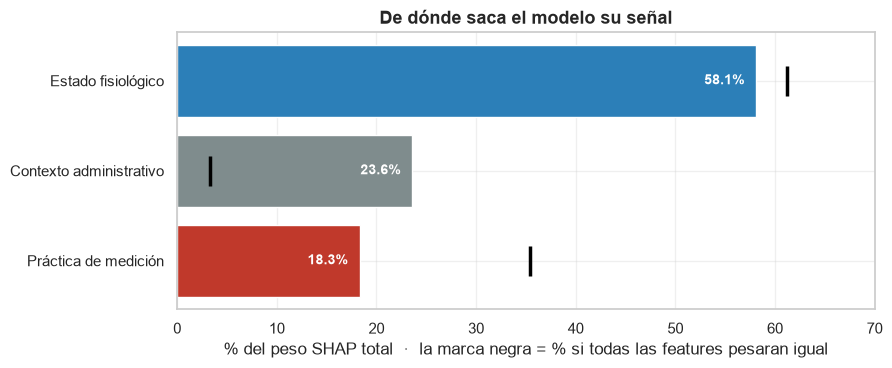

In [5]:
COLORES = {"Estado fisiológico": viz.COLOR_CONTROL,
           "Práctica de medición": viz.COLOR_SEPSIS,
           "Contexto administrativo": "#7f8c8d"}

orden = por_familia.sort_values("shap_total", ascending=True)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(orden.index, orden["% del peso total"], color=[COLORES[f] for f in orden.index])

# La marca negra es el % que tendría cada familia si todas las features pesaran igual.
for y, (fam, fila) in enumerate(orden.iterrows()):
    ax.plot([fila["% de las features"]], [y], marker="|", ms=22, color="black", mew=2.5)
    ax.text(fila["% del peso total"] - 1.2, y, f'{fila["% del peso total"]:.1f}%',
            va="center", ha="right", fontsize=10, color="white", fontweight="bold")

ax.set_xlabel("% del peso SHAP total  ·  la marca negra = % si todas las features pesaran igual")
ax.set_title("De dónde saca el modelo su señal")
ax.set_xlim(0, 70);
viz.guardar(fig, "08_shap_peso_por_familia", cfg)

La **práctica de medición pesa 18,3% con el 35,4% de las columnas** — por debajo de lo que le
tocaría si todas pesaran igual. El modelo *no* se apoya desproporcionadamente en qué decidió
medir el hospital; la preocupación del notebook 06 no se confirma para este bloque.

El desbalance está en otro lado: **7 features de contexto administrativo (3,3% de las
columnas) se llevan el 23,6% del peso** — más de 7 veces su cuota proporcional. Siete
variables que no describen ni fisiología ni práctica de medición, sino cuánto lleva internado
el paciente, cuándo ingresó y en qué unidad, concentran casi una cuarta parte de la señal.

## 3. Las 15 variables que más pesan, una por una

El agregado por familia responde "de dónde viene la señal"; esta tabla responde "cuáles en
concreto", que es lo que se puede contrastar contra la fisiología conocida de la sepsis.


WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_shap_top15_variables.png')

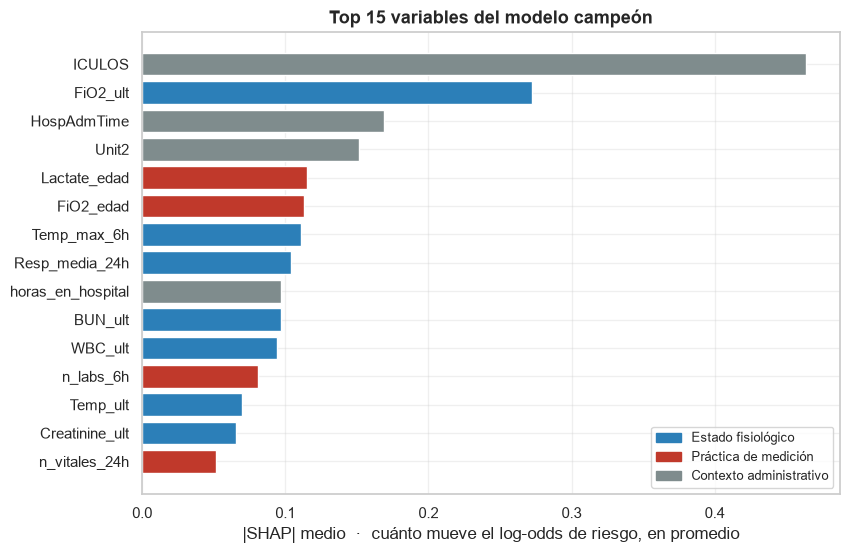

In [6]:
top = importancia.nlargest(15, "shap_medio_abs").iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"], top["shap_medio_abs"], color=[COLORES[f] for f in top["familia"]])
ax.set_xlabel("|SHAP| medio  ·  cuánto mueve el log-odds de riesgo, en promedio")
ax.set_title("Top 15 variables del modelo campeón")

manijas = [plt.Rectangle((0, 0), 1, 1, color=c) for c in COLORES.values()]
ax.legend(manijas, COLORES.keys(), fontsize=9, loc="lower right");
viz.guardar(fig, "08_shap_top15_variables", cfg)

Aquí se ve de dónde sale el desbalance. **Tres de las cuatro variables más influyentes de todo
el modelo no dicen nada sobre el estado del paciente:**

| # | Variable | Qué es realmente |
|---|---|---|
| 1 | `ICULOS` | horas que lleva el paciente en la UCI |
| 2 | `FiO2_ult` | fracción de oxígeno inspirado — la única fisiológica del top-4 |
| 3 | `HospAdmTime` | cuándo ingresó al hospital respecto a la UCI |
| 4 | `Unit2` | en qué unidad de UCI está |

Y aun `FiO2_ult` es ambigua: no es un signo vital que el cuerpo produce solo, es la dosis de
soporte respiratorio que *decidió* poner el equipo tratante. `Temp_max_6h` (puesto 7) es la
primera variable inequívocamente fisiológica del ranking.

`Unit2` es el patrón más marcado del gráfico después de `ICULOS`: unidad quirúrgica empuja el
riesgo con fuerza hacia **abajo**, casi como una regla binaria.

En parte es legítimo — más días en UCI sí es más riesgo acumulado, y la unidad sí correlaciona
con el perfil de riesgo de base. Pero tiene dos consecuencias que hay que decir en voz alta:

1. **Explica la caída entre hospitales del notebook 06.** `Unit2` y `HospAdmTime` codifican
   cómo está organizado *ese* hospital. Un modelo que gasta casi un cuarto de su señal en
   contexto administrativo no puede generalizar del todo a un centro con otra estructura de
   unidades — coherente con la caída de AUROC de ~0,84-0,85 a ~0,68-0,75 al cruzar.
2. **Parte del acierto es "lleva mucho tiempo aquí" o "está en tal unidad", no "está
   enfermando".** Un score que sube con la estancia acierta en promedio, pero no aporta
   información nueva a un clínico que ya sabe esos dos datos.

Esto no invalida el modelo — la señal fisiológica está y apunta bien — pero sí acota qué se
puede prometer de él.

## 3.1 Gráficos de dependencia: cómo cambia el efecto según el valor

El top-15 dice *cuánto* pesa cada variable; los gráficos de dependencia muestran, para las 4
que más pesan, cómo cambia su efecto sobre el riesgo a medida que cambia su propio valor — y
si ese cambio depende del valor de una segunda variable (el color, elegido automáticamente por
SHAP como la que más interactúa).

WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_shap_dependencia_top4_variables.png')

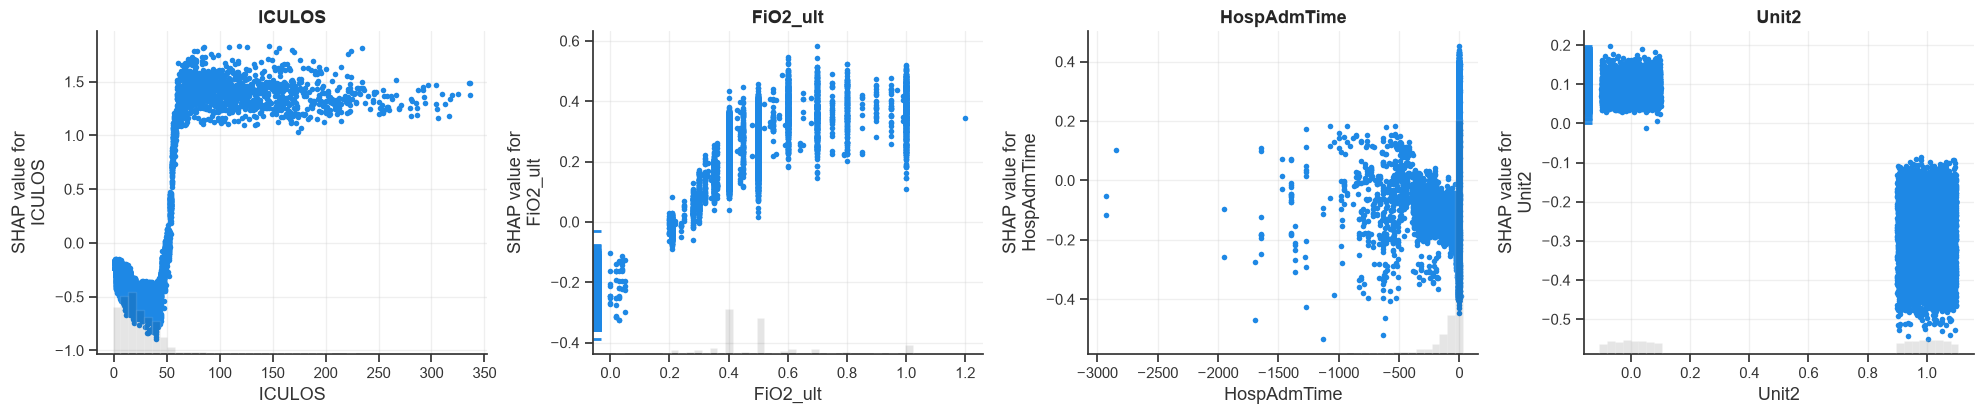

In [7]:
top4 = importancia.nlargest(4, "shap_medio_abs")["feature"].tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 4.3))
for ax, feat in zip(axes, top4):
    plt.sca(ax)
    shap.plots.scatter(shap_exp[:, feat], ax=ax, show=False)
    ax.set_title(feat)
plt.tight_layout()
viz.guardar(fig, "08_shap_dependencia_top4_variables", cfg)

Los cuatro efectos tienen una forma reconocible, no una nube dispersa sin patrón:

- **`ICULOS`**: relación casi lineal creciente — cada hora adicional suma riesgo. La variable
  que más se comporta como "reloj de exposición acumulada".
- **`FiO2_ult`**: también creciente, pero con más dispersión — señal de que interactúa con
  otras variables (probablemente qué tan grave llegó el paciente).
- **`HospAdmTime`**: el efecto más plano de los cuatro — más riesgo cuanto más rápida fue la
  llegada a UCI tras el ingreso, coherente con el notebook 01, pero un efecto modesto.
- **`Unit2`**: el más distinto — no es una curva, es casi un salto entre dos valores. La marca
  más clara de que el modelo la usa casi como una regla binaria, no como señal gradual.

## 4. Dos pacientes concretos: uno detectado y uno no

La importancia global dice en qué se fija el modelo *en promedio*. Para confiar en él hace
falta ver una decisión individual completa: qué lo llevó a alarmar en un paciente séptico, y
qué lo dejó callado en otro.

Elegimos los dos casos con una regla explícita, no a dedo: entre los pacientes sépticos del
test, el detectado con más anticipación y uno que nunca cruzó el umbral antes del evento.

In [8]:
sept = test[test.groupby("pid", observed=True)["SepsisLabel"].transform("max") == 1]

resumen = []
for pid, g in sept.groupby("pid", observed=True, sort=False):
    t_label = g.loc[g.SepsisLabel == 1, "ICULOS"].min()
    previas = g.loc[(g.alarma == 1) & (g.ICULOS <= t_label), "ICULOS"]
    resumen.append({"pid": pid, "t_label": t_label,
                    "t_alarma": previas.min() if len(previas) else np.nan,
                    "anticipacion": t_label - previas.min() if len(previas) else np.nan})
resumen = pd.DataFrame(resumen)

# Reglas explícitas de selección (no a dedo): exigimos >=24h de estancia antes del evento
# en los dos casos, para no elegir un acierto trivial (alarma casi al ingreso) ni un fallo
# injusto (paciente sin historia todavía). Del lado detectado, la anticipación MEDIANA
# -un caso representativo, no el más favorable-; del lado fallido, la mayor estancia
# previa al evento -el fallo menos excusable, con más datos disponibles-.
con_historia = resumen[resumen["t_label"] >= 24]

detectados = con_historia.dropna(subset=["anticipacion"])
pid_ok = detectados.iloc[(detectados["anticipacion"] - detectados["anticipacion"].median()).abs().argsort().iloc[0]]

fallidos = con_historia[con_historia["anticipacion"].isna()]
pid_fallo = fallidos.loc[fallidos["t_label"].idxmax()]

print(f"sépticos en test: {len(resumen)} | con >=24 h antes del evento: {len(con_historia)} "
      f"({len(detectados)} detectados, {len(fallidos)} no detectados)")
print(f"anticipación mediana entre los detectados: {detectados['anticipacion'].median():.0f} h")
print(f"\ncaso detectado   : pid {pid_ok.pid} — alarma en ICULOS {pid_ok.t_alarma:.0f}, "
      f"sepsis en {pid_ok.t_label:.0f} ({pid_ok.anticipacion:.0f} h de anticipación)")
print(f"caso no detectado: pid {pid_fallo.pid} — sepsis en ICULOS {pid_fallo.t_label:.0f}, "
      f"nunca cruzó el umbral pese a {pid_fallo.t_label:.0f} h de estancia previa")

sépticos en test: 551 | con >=24 h antes del evento: 306 (202 detectados, 104 no detectados)
anticipación mediana entre los detectados: 54 h

caso detectado   : pid p008736 — alarma en ICULOS 56, sepsis en 110 (54 h de anticipación)
caso no detectado: pid p117320 — sepsis en ICULOS 153, nunca cruzó el umbral pese a 153 h de estancia previa


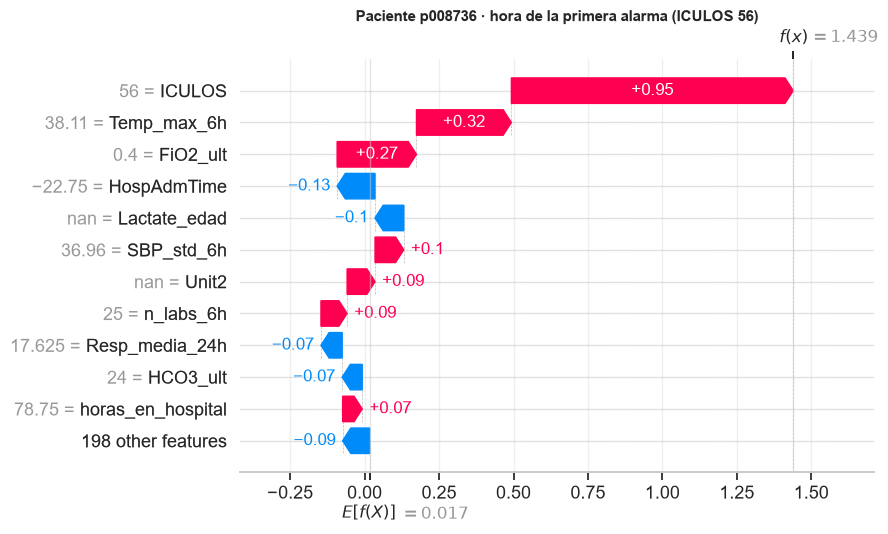

WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_shap_waterfall_paciente_detectado.png')

In [9]:
from IPython.display import display

def explicar(pid, iculos, titulo):
    plt.close("all")  # shap.plots.waterfall dibuja sobre la figura ya abierta (usa
                       # plt.gcf()/plt.gca() en vez de crear una propia) -- sin este
                       # cierre, la segunda llamada quedaba dibujada encima de la primera.
    fila = test[(test.pid == pid) & (test.ICULOS == iculos)]
    exp = explicador(fila[cols])
    shap.plots.waterfall(exp[0], max_display=12, show=False)
    plt.ion()  # shap.plots.waterfall(show=False) llama plt.ioff() y nunca lo revierte,
               # lo que apaga la vista previa automática de matplotlib para TODAS las
               # celdas siguientes del notebook -- se reactiva aquí mismo.
    fig = plt.gcf()
    fig.set_size_inches(9, 5.5)
    plt.title(titulo, fontsize=11, fontweight="bold")
    plt.tight_layout()
    display(fig)  # el propio ioff() de arriba también silencia la vista previa de ESTA
                  # celda (reactivar el modo interactivo no llega a tiempo para ella) --
                  # se fuerza explícitamente para no depender de ese comportamiento.
    return fila

fila_ok = explicar(pid_ok.pid, pid_ok.t_alarma,
                   f"Paciente {pid_ok.pid} · hora de la primera alarma (ICULOS {pid_ok.t_alarma:.0f})")
viz.guardar(plt.gcf(), "08_shap_waterfall_paciente_detectado", cfg)

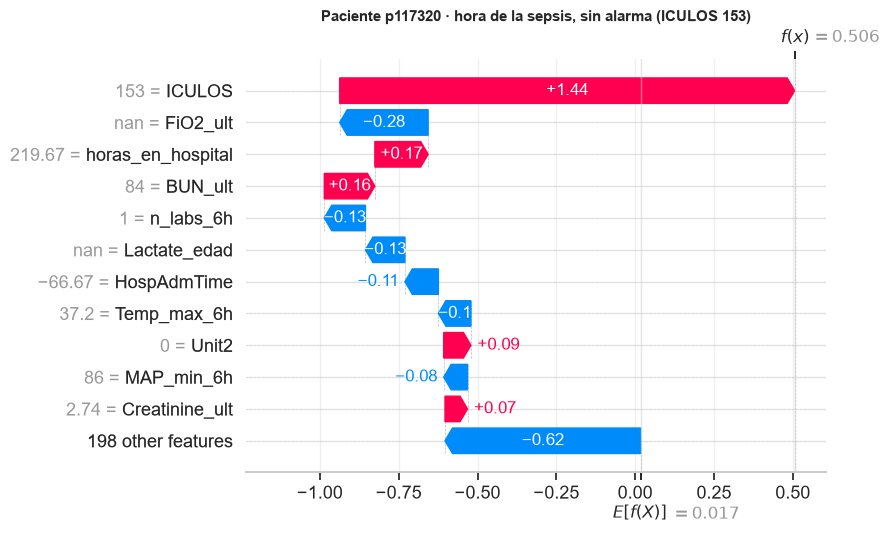

WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_shap_waterfall_paciente_no_detectado.png')

In [10]:
# El fallo, explicado en la hora de la etiqueta: qué veía el modelo justo cuando no alarmó.
fila_fallo = explicar(pid_fallo.pid, pid_fallo.t_label,
                      f"Paciente {pid_fallo.pid} · hora de la sepsis, sin alarma (ICULOS {pid_fallo.t_label:.0f})")
viz.guardar(plt.gcf(), "08_shap_waterfall_paciente_no_detectado", cfg)

In [11]:
# La evidencia cruda detrás de las dos explicaciones: qué valores tenía cada paciente.
clinicas = ["HR_ult", "Temp_ult", "MAP_ult", "Resp_ult", "O2Sat_ult", "WBC_ult", "Lactate_ult",
            "Creatinine_ult", "indice_shock", "qsofa_parcial", "sirs_total"]
comparacion = pd.concat([
    fila_ok[["pid", "ICULOS", "score"] + clinicas].assign(caso="detectado"),
    fila_fallo[["pid", "ICULOS", "score"] + clinicas].assign(caso="no detectado"),
]).set_index("caso")
comparacion.round(2)


,pid,ICULOS,score,HR_ult,Temp_ult,MAP_ult,Resp_ult,O2Sat_ult,WBC_ult,Lactate_ult,Creatinine_ult,indice_shock,qsofa_parcial,sirs_total
caso,,,,,,,,,,,,,,
detectado,p008736,56,0.81,88.0,37.060001,56.5,15.0,100.0,7.3,NaN,0.70,0.87,0.0,0.0
no detectado,p117320,153,0.62,100.0,37.000000,93.0,16.0,94.5,12.2,NaN,2.74,0.73,0.0,2.0


Los dos casos matizan la lectura agregada de las secciones 2 y 3 más de lo que la confirman.

**El acierto (p008736) no se explica solo con fisiología, aunque la fisiología también está
presente.** La alarma salta en la hora 56 de estancia: `ICULOS` es, con diferencia, el mayor
contribuyente individual (+0,947). Pero `Temp_max_6h` de 38,1°C (fiebre real, +0,319) y
`FiO2_ult` de 0,40 (soporte de oxígeno, +0,266) también empujan, con señal clínica genuina. Es
un acierto mixto: el reloj administrativo hace la mayor parte del trabajo, pero no todo.

**El fallo (p117320) es el caso más instructivo del notebook**: el modelo tenía *más* señal de
`ICULOS` que en el acierto (+1,443, en la hora 153) y aun así no alarmó. `BUN_ult` de 84
mg/dL (fallo renal severo) suma +0,160 más. Pese a eso, el score se queda en 0,506, muy por
debajo del umbral (0,7838). La razón: tres señales de **baja intensidad de vigilancia** tiran
en contra — `FiO2_ult` sin medir (−0,280), solo 1 laboratorio en las últimas 6 horas (−0,131)
y lactato sin medir (−0,125). El equipo clínico no vigilaba a este paciente con la misma
intensidad que a los detectados a tiempo, y el modelo, que aprendió que la vigilancia es señal
real (notebook 02), termina descontando un laboratorio genuinamente anormal.

Este es exactamente el tipo de caso que el agregado no puede ver: la práctica de medición pesa
menos de lo esperado *en promedio*, pero en un caso concreto puede ser la diferencia entre
alarmar y no alarmar.

## 5. Diagnóstico complementario: Yellowbrick y el umbral de decisión

SHAP responde *en qué se fija* el modelo; esta sección cierra con diagnósticos "clásicos" de
clasificación. `ROCAUC` desagrega la curva por clase; `ClassificationReport` la muestra como
mapa de calor.

Dos incompatibilidades reales, encontradas y documentadas (no parcheadas en silencio):

- Yellowbrick exige que el modelo herede de una clase base de scikit-learn, y `CatBoost` no lo
  hace (implementa la misma interfaz sin heredar de ella). Se resuelve envolviéndolo con
  `yellowbrick.contrib.wrapper.classifier`, pensado para este caso.
- El análisis de umbral nativo de Yellowbrick reentrena el modelo por validación cruzada, algo
  incompatible con el *early stopping* del notebook 06. En su lugar usamos una función propia
  que analiza el umbral sin reentrenar nada.

WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_rocauc_por_clase.png')

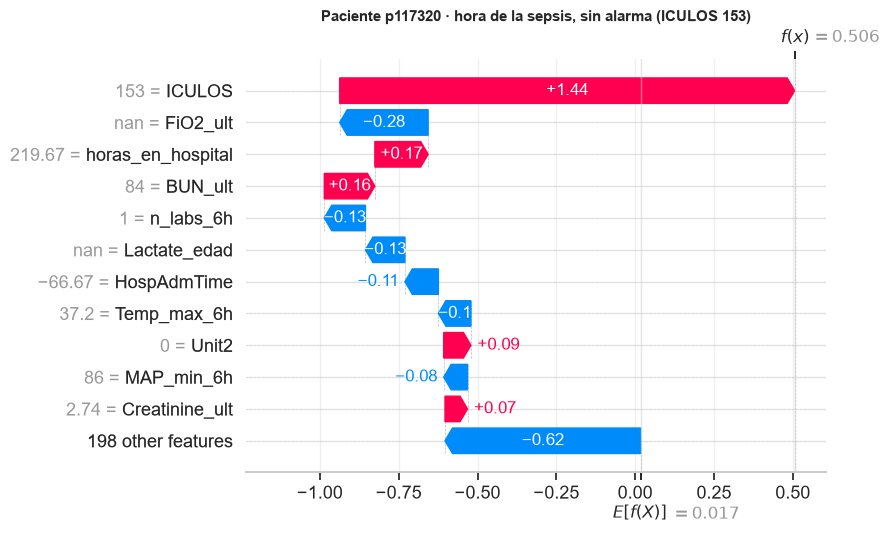

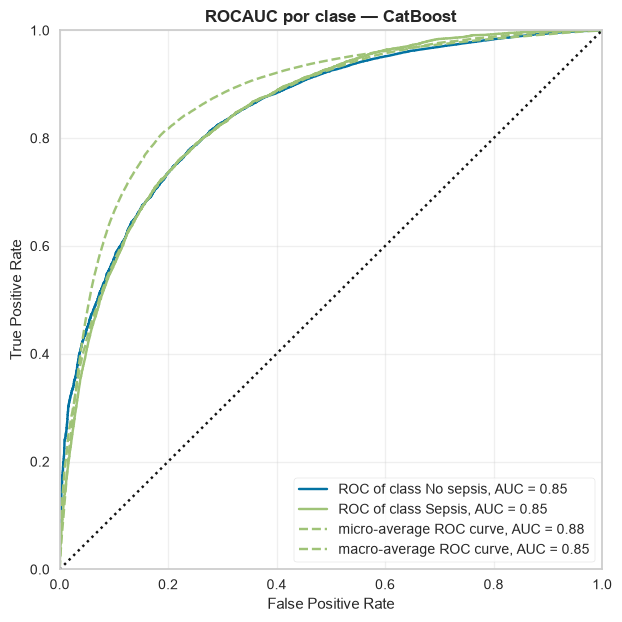

In [12]:
from yellowbrick.classifier import ROCAUC, ClassificationReport
from yellowbrick.contrib.wrapper import classifier as yb_classifier

# CatBoost no hereda de sklearn.base.BaseEstimator, así que se envuelve con el wrapper de
# contrib de Yellowbrick; y aunque is_fitted=True evita reentrenar el modelo, el propio
# visualizador igual necesita su .fit() (no solo .score()) para fijar target_type_/classes_.
X_campeon = test[cols]
if "imputer" in campeon:
    X_campeon = campeon["scaler"].transform(campeon["imputer"].transform(X_campeon))
y_campeon = test["SepsisLabel"]

modelo_yb = yb_classifier(modelo)

fig, ax = plt.subplots(figsize=(7, 7))
rocauc = ROCAUC(modelo_yb, classes=["No sepsis", "Sepsis"], is_fitted=True, ax=ax)
rocauc.fit(X_campeon, y_campeon)
rocauc.score(X_campeon, y_campeon)
rocauc.finalize()
plt.title(f"ROCAUC por clase — {NOMBRE_CAMPEON}");
viz.guardar(fig, "08_rocauc_por_clase", cfg)

WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_classification_report_heatmap.png')

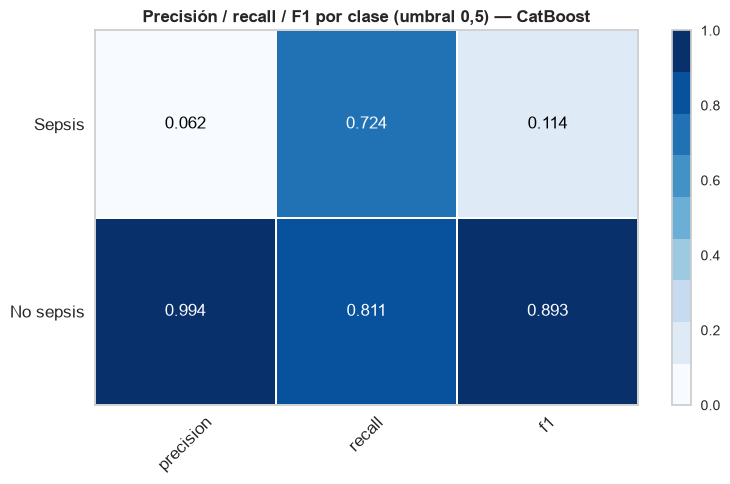

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
reporte = ClassificationReport(modelo_yb, classes=["No sepsis", "Sepsis"], cmap="Blues",
                                is_fitted=True, ax=ax)
reporte.fit(X_campeon, y_campeon)
reporte.score(X_campeon, y_campeon)
reporte.finalize()
plt.title(f"Precisión / recall / F1 por clase (umbral 0,5) — {NOMBRE_CAMPEON}");
viz.guardar(fig, "08_classification_report_heatmap", cfg)

WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_precision_recall_f1_vs_umbral.png')

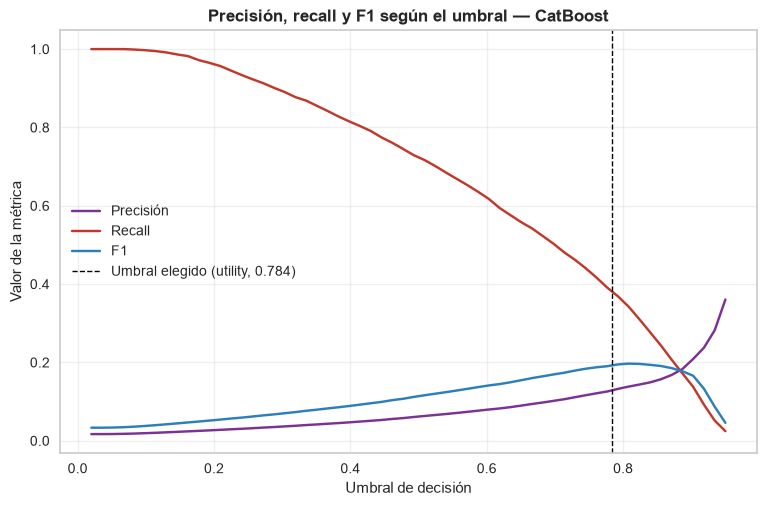

In [14]:
viz.precision_recall_f1_vs_umbral(test["SepsisLabel"], test["score"], umbral_elegido=UMBRAL)
plt.title(f"Precisión, recall y F1 según el umbral — {NOMBRE_CAMPEON}");
viz.guardar(plt.gcf(), "08_precision_recall_f1_vs_umbral", cfg)

`ROCAUC` desagregada confirma el número global del notebook 07 (0,8497) sin que ninguna clase
quede escondida detrás del promedio. `ClassificationReport`, al umbral por defecto de 0,5,
muestra el mismo desequilibrio del notebook 06: recall alto para sepsis (0,724) pero precisión
muy baja (0,062) — la mayoría de las alarmas son falsas. Es la versión "de manual" del mismo
argumento: a 0,5 el modelo parece funcionar mal, pero 0,5 nunca tuvo significado clínico aquí.

La curva de umbral trae un resultado inesperado: el umbral que maximiza F1 (0,808) queda
**cerca** del elegido por utility (0,7838), no lejos. No es que F1 y utility discrepen en este
punto concreto — lo que discrepa es **cómo llegan ahí**: F1 maximiza un balance ciego entre dos
errores que no cuestan lo mismo; utility llega a una zona parecida por una razón clínica
explícita. Que coincidan aquí es una casualidad de este modelo y esta prevalencia, no una
garantía — el notebook 07 ya mostró que el ranking *entre modelos* sí cambia según se optimice
AUPRC o utility.

## 6. ¿Qué es exactamente la sepsis, y por qué el techo de predicción es bajo?

Todo lo anterior mide qué tan bien predice el modelo. Falta la pregunta de fondo: ¿qué tan
predecible es la sepsis, en principio, con los datos que existen?

**Cómo se etiquetó `SepsisLabel`** ([Reyna et al. 2019](https://www.cinc.org/archives/2019/pdf/CinC2019-412.pdf),
criterio clínico Sepsis-3): tres tiempos, no un valor de laboratorio.

- **t_sospecha** — cuándo se pidieron antibióticos y cultivos de sangre.
- **t_SOFA** — cuándo aparece falla orgánica (un aumento de 2 puntos en el score SOFA).
- **t_sepsis** — el más temprano de los dos anteriores. `SepsisLabel` ya viene desplazada 6h
  hacia atrás respecto a t_sepsis (`src/utility.py`).

Dos cosas de esta definición no aparecen en ninguna columna del dataset: depende de una
**decisión médica** (pedir antibióticos, pedir cultivos), no solo de fisiología medida, y la
mitad de la definición (t_SOFA) exige un score compuesto de 6 sistemas de órganos que este
dataset no alcanza a reconstruir del todo.

In [15]:
sofa_componentes = pd.DataFrame([
    {"sistema": "Respiratorio", "criterio_real": "razón PaO2/FiO2", "en_el_dataset": "Solo FiO2 (falta PaO2)"},
    {"sistema": "Coagulación", "criterio_real": "plaquetas", "en_el_dataset": "Sí (Platelets)"},
    {"sistema": "Hígado", "criterio_real": "bilirrubina", "en_el_dataset": "Sí (Bilirubin_total)"},
    {"sistema": "Cardiovascular", "criterio_real": "MAP y dosis de vasopresores", "en_el_dataset": "Solo MAP (faltan vasopresores)"},
    {"sistema": "Sistema nervioso", "criterio_real": "escala de coma de Glasgow", "en_el_dataset": "No está en las 40 variables"},
    {"sistema": "Renal", "criterio_real": "creatinina", "en_el_dataset": "Sí (Creatinine)"},
]).set_index("sistema")
sofa_componentes

,criterio_real,en_el_dataset
sistema,,
Respiratorio,razón PaO2/FiO2,Solo FiO2 (falta PaO2)
Coagulación,plaquetas,Sí (Platelets)
Hígado,bilirrubina,Sí (Bilirubin_total)
Cardiovascular,MAP y dosis de vasopresores,Solo MAP (faltan vasopresores)
Sistema nervioso,escala de coma de Glasgow,No está en las 40 variables
Renal,creatinina,Sí (Creatinine)


De los 6 sistemas que definen la mitad de la etiqueta, a este dataset le faltan dos por
completo (sistema nervioso, y la dosis de vasopresores del cardiovascular) y el respiratorio
solo llega a la mitad (`FiO2` sin `PaO2`). Ningún modelo puede reconstruir un score que
depende de información que el dataset nunca contuvo — no es una limitación de este pipeline,
es una limitación estructural de los datos.

**¿Y las variables que sí tenemos? ¿Qué tan bien separan, en crudo, a un séptico de uno que no
lo es?** Se mide con el solapamiento entre las dos distribuciones (curvas de densidad): 100%
significaría indistinguibles, 0% que no se tocan.

WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_solapamiento_variables_criticas.png')

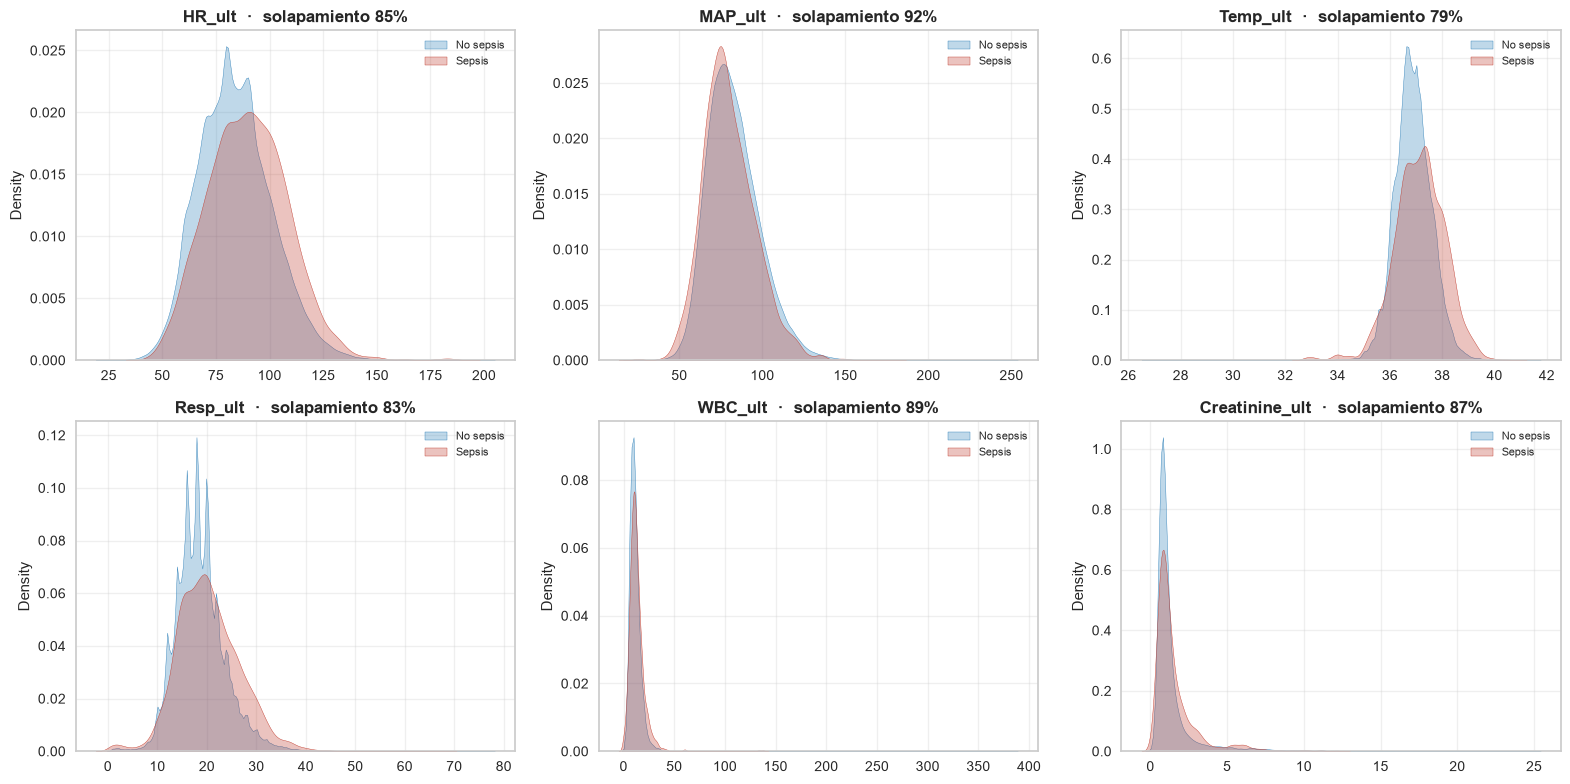

In [16]:
def solapamiento(a, b, bins=60):
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    ha, _ = np.histogram(a, bins=bins, range=(lo, hi), density=True)
    hb, _ = np.histogram(b, bins=bins, range=(lo, hi), density=True)
    return (np.minimum(ha, hb) * (hi - lo) / bins).sum()


vars_solapamiento = ["HR_ult", "MAP_ult", "Temp_ult", "Resp_ult", "WBC_ult", "Creatinine_ult"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, var in zip(axes.flat, vars_solapamiento):
    control = test.loc[test.SepsisLabel == 0, var].dropna()
    sepsis = test.loc[test.SepsisLabel == 1, var].dropna()
    pct = solapamiento(control, sepsis) * 100
    sns.kdeplot(control, color=viz.COLOR_CONTROL, fill=True, alpha=0.3, ax=ax, label="No sepsis")
    sns.kdeplot(sepsis, color=viz.COLOR_SEPSIS, fill=True, alpha=0.3, ax=ax, label="Sepsis")
    ax.set_title(f"{var}  ·  solapamiento {pct:.0f}%")
    ax.set_xlabel("")
    ax.legend(fontsize=8)
plt.tight_layout()
viz.guardar(fig, "08_solapamiento_variables_criticas", cfg)

El solapamiento es alto en las seis variables, **entre 79% y 92%** — incluso en las que SHAP
señaló como más influyentes. `Temp_ult` es la más separable (79,3%) y aun así casi 4 de cada 5
valores caen donde ambas curvas se superponen. `MAP_ult` es la más solapada (92,4%): la media
apenas cambia entre grupos, coherente con el notebook 01 (la presión cae *después* del evento,
no antes).

Esto no contradice lo que ya mostró SHAP — el modelo sí encuentra señal real, y en la
dirección correcta — lo complementa: la señal existe en la *combinación* de docenas de
variables y su *tendencia* en el tiempo, nunca en el valor aislado de una sola. Es la razón de
fondo, no solo de datos sino de la propia biología de la sepsis, por la que el techo de AUPRC
de este problema está donde está.

## 6.1 Aun siendo difícil, detectar temprano sí importa clínicamente

Todo lo anterior explica por qué el techo de predicción es bajo — variables que se solapan
mucho, una etiqueta que depende de decisiones médicas y de un score que el dataset no puede
reconstruir del todo. Pero eso no significa que "adelantarse un poco" no valga la pena.

El estudio clínico más citado sobre esto es Kumar et al. (2006, *Critical Care Medicine*,
2.731 pacientes con choque séptico): **cada hora de retraso en iniciar el antibiótico
correcto, contada desde que empieza la hipotensión, se asoció a un 7,6% más de mortalidad en
promedio** (rango 3,6%-9,9% entre los distintos análisis del estudio) — el mismo dato que
citamos en el README. El gráfico de abajo no reproduce la figura original del paper (tiene
copyright); es una reconstrucción propia de esa tasa reportada, para ilustrar el orden de
magnitud del efecto.

WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/08_mortalidad_vs_horas_retraso_tratamiento.png')

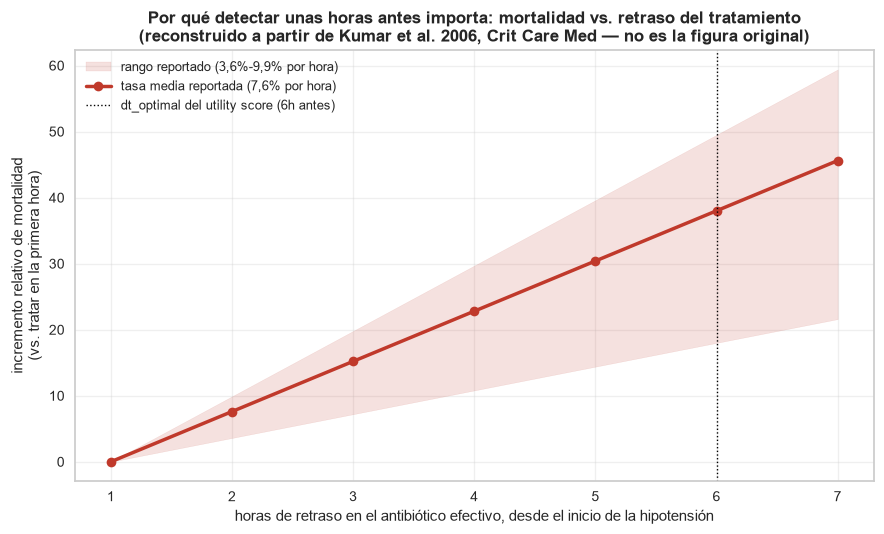

In [17]:
horas = np.arange(1, 8)
tasa_media, tasa_baja, tasa_alta = 0.076, 0.036, 0.099

incremento_medio = (horas - 1) * tasa_media * 100
incremento_bajo = (horas - 1) * tasa_baja * 100
incremento_alto = (horas - 1) * tasa_alta * 100

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.fill_between(horas, incremento_bajo, incremento_alto, color=viz.COLOR_SEPSIS, alpha=0.15,
                label="rango reportado (3,6%-9,9% por hora)")
ax.plot(horas, incremento_medio, color=viz.COLOR_SEPSIS, lw=2.5, marker="o",
        label="tasa media reportada (7,6% por hora)")
ax.axvline(6, color="black", ls=":", lw=1, label="dt_optimal del utility score (6h antes)")

ax.set_xlabel("horas de retraso en el antibiótico efectivo, desde el inicio de la hipotensión")
ax.set_ylabel("incremento relativo de mortalidad\n(vs. tratar en la primera hora)")
ax.set_title("Por qué detectar unas horas antes importa: mortalidad vs. retraso del tratamiento\n"
             "(reconstruido a partir de Kumar et al. 2006, Crit Care Med — no es la figura original)")
ax.legend(fontsize=9)
plt.tight_layout()
viz.guardar(fig, "08_mortalidad_vs_horas_retraso_tratamiento", cfg)


**Lectura:** a 6 horas de retraso —justo la ventana que el utility score del proyecto premia
más (`dt_optimal`, notebook 07)— el incremento medio de mortalidad reportado ronda el 38%
frente a tratar en la primera hora, con un rango de 18% a 50% según el análisis. No hace falta
que el modelo sea perfecto para que valga la pena: aunque el techo de AUPRC sea bajo (Sección
6), cada hora de anticipación real que gane el modelo campeón (mediana de 45h en los pacientes
que sí detecta, notebook 07) es, clínicamente, una hora que puede cambiar el desenlace de un
paciente.

In [18]:
destino = cfg["rutas"]["dashboard"]
destino.mkdir(parents=True, exist_ok=True)

salida = importancia.sort_values("shap_medio_abs", ascending=False)
salida.to_csv(destino / "importancia_shap.csv", index=False)
print(f"Guardado en {(destino / 'importancia_shap.csv').relative_to(cfg['raiz'])} ({len(salida)} filas)")


Guardado en reports\dashboard\importancia_shap.csv (209 filas)


## 8. Qué sabemos al cerrar este notebook

- **La señal fisiológica existe y apunta en la dirección correcta.** Fiebre, taquipnea,
  leucocitosis y deterioro renal empujan todos el riesgo hacia arriba, como manda la
  fisiopatología de la sepsis.
- **Pero tres de las cuatro variables más influyentes no describen al paciente**: `ICULOS`,
  `HospAdmTime` y `Unit2`. La única clínica del top-4, `FiO2_ult`, es en sí misma una decisión
  del equipo tratante, no un signo vital espontáneo.
- **El contexto administrativo está sobre-representado más de 7 veces**: 7 features (3,3% de
  las columnas) concentran el 23,6% del peso SHAP.
- **La práctica de medición, como bloque, pesa menos de lo que le tocaría** (18,3% del peso
  con 35,4% de las columnas) — esa preocupación en particular no se confirma.
- **Esto explica la caída entre hospitales del notebook 06.** `Unit2` y `HospAdmTime`
  codifican la organización de *ese* hospital, no fisiología transferible.
- **Los dos casos individuales matizan el agregado.** El acierto combina un aporte fuerte de
  `ICULOS` con fiebre y soporte de oxígeno reales. El fallo tenía más señal de `ICULOS` que el
  acierto y un `BUN` de 84 mg/dL (fallo renal severo), y aun así no alarmó — tres señales de
  baja vigilancia clínica pesaron más que ese valor anormal.
- **La sepsis se define por decisiones médicas y un score de 6 órganos, y este dataset no
  alcanza a reconstruir 2 de esos 6** (sistema nervioso, mitad del respiratorio) — un techo de
  predictibilidad que ningún modelo puede superar solo con mejor código.
- **Consecuencia para la entrega**: el modelo es defendible como tamizaje en un hospital cuyos
  datos vio durante el entrenamiento; hay que declarar que parte de su desempeño depende de
  contexto administrativo que no viaja a otro centro, y que puede ignorar un laboratorio
  anormal si llega con poca vigilancia alrededor.

➡️ Siguiente: exportar el resto de insumos para el **dashboard** y escribir el `README.md`.